# SAB Consistency Validation Review

This notebook visualizes the SAB consistency validation outputs. It is for review only; it does not modify metadata or image files.

Use it to inspect:
- source convergence between current metadata and SAB folders/splits;
- critical cases such as OSCC/carcinoma patches in benign/no-dysplasia origin context;
- medium cases such as dysplasia patches in benign/no-dysplasia origin context;
- example image panels for each flag type.

In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from IPython.display import clear_output, display

try:
    import ipywidgets as widgets
except ImportError as exc:
    raise ImportError("ipywidgets is required. Open with: uv run --with ipywidgets --with notebook jupyter lab") from exc

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
VALIDATION_DIR = REPO_ROOT / 'results/phase0_sab_consistency_validation'

patch_origin = pd.read_csv(VALIDATION_DIR / 'patch_origin_plausibility_validation.csv')
patch_source = pd.read_csv(VALIDATION_DIR / 'patch_source_convergence.csv')
origin_source = pd.read_csv(VALIDATION_DIR / 'origin_source_convergence.csv')
case_summary = pd.read_csv(VALIDATION_DIR / 'case_prefix_plausibility_summary.csv')
summary = json.loads((VALIDATION_DIR / 'validation_summary.json').read_text())

print(f'Loaded validation from {VALIDATION_DIR}')
print(f"patch rows: {len(patch_origin)}")
print(f"origin rows: {len(origin_source)}")
print(f"case prefixes: {len(case_summary)}")

Loaded validation from /Volumes/ssd/thesis_organization/ndb_ufes_data_organizer/results/phase0_sab_consistency_validation
patch rows: 3763
origin rows: 242
case prefixes: 64


## Summary Counts

,metric,value
0,current_origin_images,242
1,current_origin_images_exact_matched_to_sab,222
2,current_origin_images_unmatched_to_sab,20
3,current_patch_images,3763
4,current_patch_images_exact_matched_to_sab,3763
5,current_patch_images_unmatched_to_sab,0
6,case_prefixes,64


,origin_folder_vs_current_metadata_status,count
0,broad_folder_only,137
1,agrees,77
2,no_current_origin_match,20
3,disagrees,8


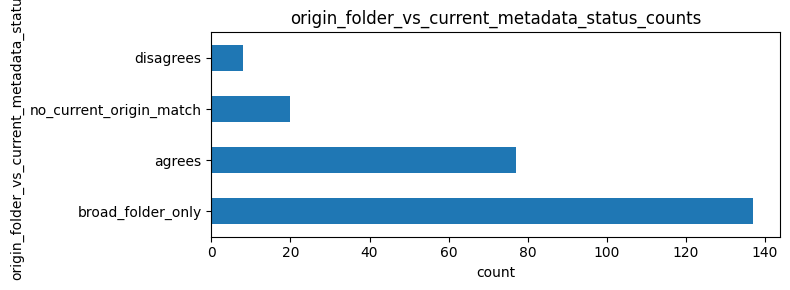

,patch_csv_vs_sab_split_status,count
0,agrees,1758
1,disagrees,1328
2,missing_current_patch_metadata,677


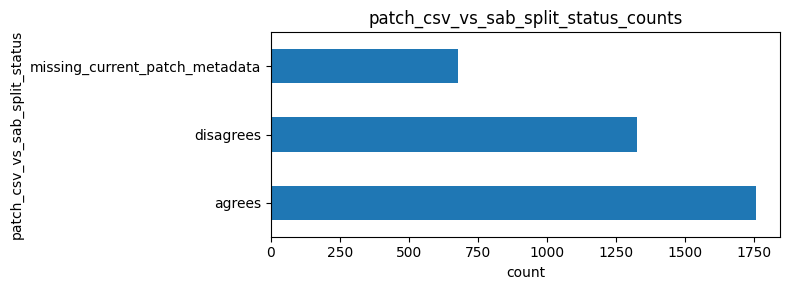

,patch_vs_origin_plausibility_status,count
0,plausible,3240
1,plausible_but_origin_patch_disagreement,421
2,impossible_or_high_conflict,102


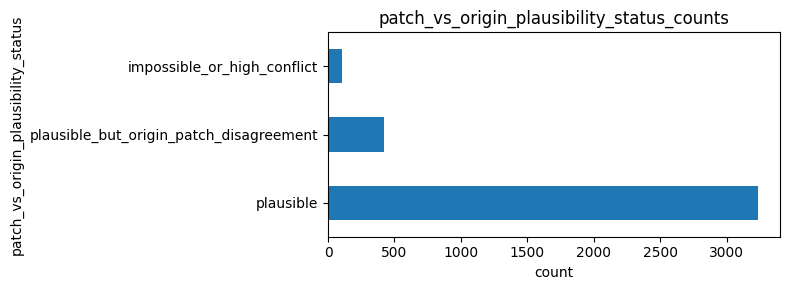

,review_priority,count
0,low,1853
1,high,1387
2,medium,421
3,critical,102


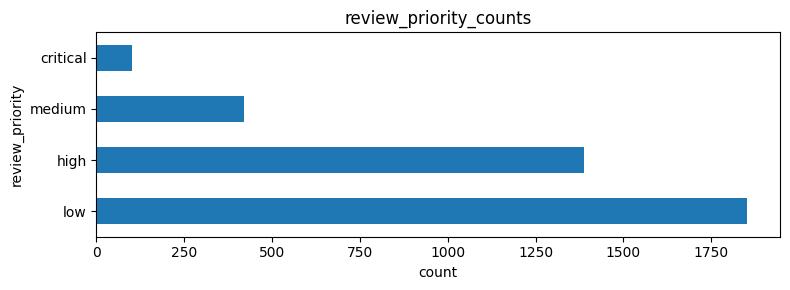

In [2]:
display(pd.DataFrame([
    {'metric': key, 'value': value}
    for key, value in summary.items()
    if not isinstance(value, dict)
]))

for key in [
    'origin_folder_vs_current_metadata_status_counts',
    'patch_csv_vs_sab_split_status_counts',
    'patch_vs_origin_plausibility_status_counts',
    'review_priority_counts',
]:
    table = pd.Series(summary[key], name='count').reset_index().rename(columns={'index': key.replace('_counts', '')})
    display(table)
    ax = table.plot(kind='barh', x=table.columns[0], y='count', legend=False, figsize=(8, 3), title=key)
    ax.set_xlabel('count')
    plt.tight_layout()
    plt.show()

## Cross-Tabs

In [3]:
display(pd.crosstab(
    patch_origin['best_available_origin_label_normalized'],
    patch_origin['best_available_patch_label_normalized'],
    margins=True,
))

display(pd.crosstab(
    patch_origin['patch_vs_origin_plausibility_status'],
    patch_origin['review_priority'],
    margins=True,
))

display(pd.crosstab(
    patch_origin['current_patch_label_normalized'],
    patch_origin['sab_split_label_normalized'],
    margins=True,
))

best_available_patch_label_normalized,oscc,with_dysplasia,without_dysplasia,All
best_available_origin_label_normalized,,,,
broad_leukoplakia_unknown_dysplasia,0,1,0,1
oscc,1543,21,11,1575
with_dysplasia,0,936,15,951
without_dysplasia,102,406,728,1236
All,1645,1364,754,3763


review_priority,critical,high,low,medium,All
patch_vs_origin_plausibility_status,,,,,
impossible_or_high_conflict,102,0,0,0,102
plausible,0,1387,1853,0,3240
plausible_but_origin_patch_disagreement,0,0,0,421,421
All,102,1387,1853,421,3763


sab_split_label_normalized,oscc,with_dysplasia,without_dysplasia,All
current_patch_label_normalized,,,,
oscc,932,521,64,1517
unknown,128,434,115,677
with_dysplasia,66,581,283,930
without_dysplasia,0,394,245,639
All,1126,1930,707,3763


## Example Viewer

In [4]:
def resolve_path(value):
    if pd.isna(value) or str(value).strip() == '':
        return None
    path = Path(str(value))
    return path if path.is_absolute() else REPO_ROOT / path


def open_image(value, max_size=(360, 360)):
    path = resolve_path(value)
    if path is None or not path.exists():
        return None
    image = Image.open(path).convert('RGB')
    return ImageOps.contain(image, max_size)


def show_patch_row(row):
    panels = [
        ('current NDB patch', row.get('ndb_patch_path', '')),
        ('matched SAB patch', row.get('sab_patch_path', '')),
        ('SAB origin image', row.get('sab_origin_path', '')),
        ('current NDB origin from patch CSV', row.get('ndb_origin_id_from_patch_csv', '')),
        ('current NDB origin exact-matched to SAB origin', row.get('ndb_origin_path_from_sab_origin_exact_match', '')),
    ]
    # Convert numeric current origin id to path for panel 4.
    if str(panels[3][1]).strip() and not pd.isna(panels[3][1]):
        try:
            origin_id = f"{int(float(panels[3][1])):04d}"
        except Exception:
            origin_id = str(panels[3][1]).zfill(4)
        panels[3] = (panels[3][0] + f' {origin_id}', REPO_ROOT / f'data/ndb_ufes/origin_level/images/{origin_id}.png')

    fig, axes = plt.subplots(1, len(panels), figsize=(4.0 * len(panels), 4.2))
    for ax, (title, path_value) in zip(axes, panels):
        image = open_image(path_value)
        if image is None:
            ax.text(0.5, 0.5, 'not available', ha='center', va='center')
        else:
            ax.imshow(image)
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    columns = [
        'ndb_patch', 'current_patch_diagnosis', 'sab_split_class',
        'sab_origin_image_id', 'sab_origin_folder',
        'current_origin_diagnosis_from_patch_csv',
        'current_origin_diagnosis_from_sab_origin_exact_match',
        'best_available_origin_label_normalized',
        'best_available_patch_label_normalized',
        'origin_folder_vs_current_metadata_status',
        'patch_csv_vs_sab_split_status',
        'patch_vs_origin_plausibility_status',
        'severity_direction', 'source_convergence_status', 'review_priority',
        'sab_case_prefix', 'sab_duplicate_patch_hash_match_count',
    ]
    display(pd.DataFrame(row[columns]).rename(columns={row.name: 'value'}))


priority_dropdown = widgets.Dropdown(
    options=['critical', 'high', 'medium', 'low', 'all'],
    value='critical',
    description='Priority',
)
plausibility_dropdown = widgets.Dropdown(
    options=['all'] + sorted(patch_origin['patch_vs_origin_plausibility_status'].dropna().unique().tolist()),
    value='all',
    description='Plausibility',
)
source_dropdown = widgets.Dropdown(
    options=['all'] + sorted(patch_origin['source_convergence_status'].dropna().unique().tolist()),
    value='all',
    description='Source',
)
case_box = widgets.Text(value='', description='Case prefix', placeholder='optional')
row_slider = widgets.IntSlider(value=0, min=0, max=0, description='Example')
refresh_button = widgets.Button(description='Refresh examples', button_style='primary')
output = widgets.Output()

current_examples = {'table': patch_origin.head(0)}


def filtered_examples():
    df = patch_origin.copy()
    if priority_dropdown.value != 'all':
        df = df[df['review_priority'] == priority_dropdown.value]
    if plausibility_dropdown.value != 'all':
        df = df[df['patch_vs_origin_plausibility_status'] == plausibility_dropdown.value]
    if source_dropdown.value != 'all':
        df = df[df['source_convergence_status'] == source_dropdown.value]
    if case_box.value.strip():
        df = df[df['sab_case_prefix'].fillna('').str.contains(case_box.value.strip(), regex=False)]
    return df.sort_values(['review_priority', 'ndb_patch_number']).reset_index(drop=True)


def refresh(_=None):
    df = filtered_examples()
    current_examples['table'] = df
    row_slider.max = max(0, len(df) - 1)
    row_slider.value = 0
    show_current()


def show_current(_=None):
    with output:
        clear_output(wait=True)
        df = current_examples['table']
        print(f'{len(df)} matching examples')
        if df.empty:
            return
        row = df.iloc[row_slider.value]
        print(f"Showing {row_slider.value + 1}/{len(df)}: {row['ndb_patch']}")
        show_patch_row(row)


refresh_button.on_click(refresh)
row_slider.observe(lambda change: show_current() if change.get('name') == 'value' else None, names='value')

display(widgets.VBox([
    widgets.HBox([priority_dropdown, plausibility_dropdown, source_dropdown]),
    widgets.HBox([case_box, refresh_button, row_slider]),
]), output)
refresh()

Output()

## Top Case Prefixes

,case_prefix,n_origin_images,n_patches,origin_diagnoses_seen,patch_labels_seen,n_critical_conflicts,n_high_conflicts,n_medium_conflicts
0,000.000.006-15,14,200,oscc|without_dysplasia,oscc|with_dysplasia|without_dysplasia,23,4,29
1,000.000.304-16,9,177,oscc|without_dysplasia,oscc|with_dysplasia|without_dysplasia,21,25,35
2,000.000.012-14,4,77,oscc|without_dysplasia,oscc|with_dysplasia|without_dysplasia,17,3,14
3,000.000.208-16,3,54,oscc|without_dysplasia,oscc|with_dysplasia|without_dysplasia,12,20,21
4,000.000.141-14,4,74,oscc|without_dysplasia,oscc|with_dysplasia,12,3,22
5,000.000.077-14,4,74,oscc|without_dysplasia,oscc|with_dysplasia,10,21,24
6,000.000.160-15,6,116,oscc|without_dysplasia,oscc|with_dysplasia|without_dysplasia,5,0,30
7,000.000.001-15,9,151,with_dysplasia|without_dysplasia,oscc|with_dysplasia,2,41,16
8,000.000.090-16,8,129,oscc,oscc|without_dysplasia,0,128,0
9,000.000.127-16,8,107,without_dysplasia,without_dysplasia,0,78,0


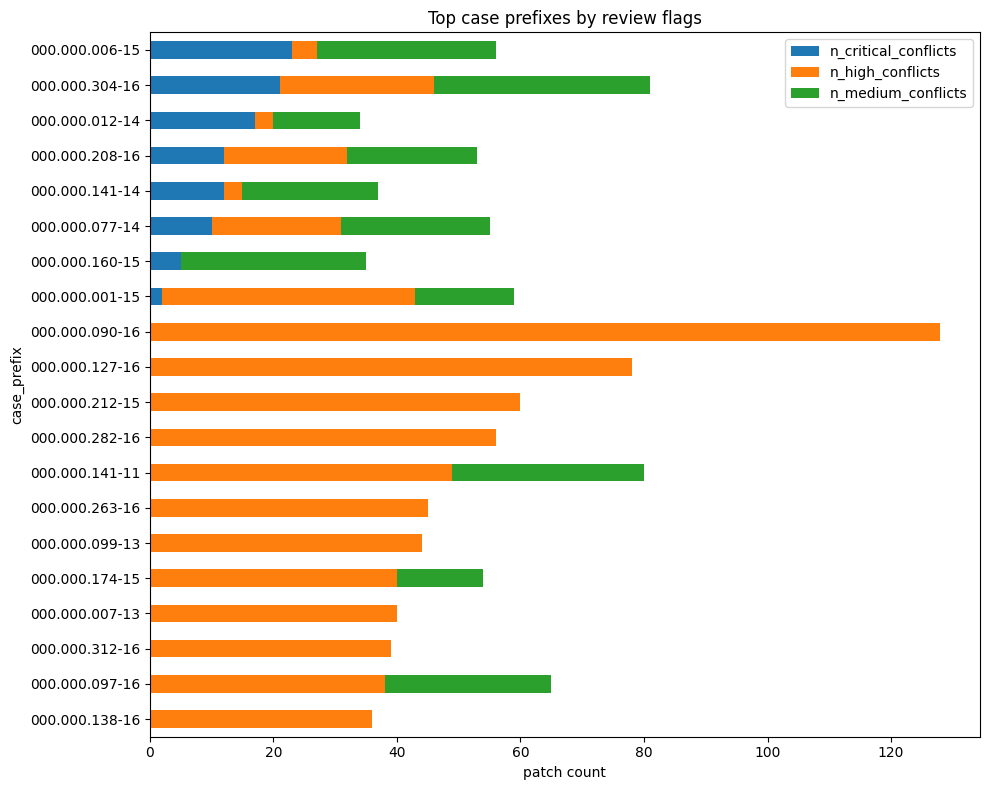

In [6]:
display(case_summary.head(30))

plot_cols = ['n_critical_conflicts', 'n_high_conflicts', 'n_medium_conflicts']
top = case_summary.head(20).set_index('case_prefix')[plot_cols]
ax = top.plot(kind='barh', stacked=True, figsize=(10, 8), title='Top case prefixes by review flags')
ax.invert_yaxis()
ax.set_xlabel('patch count')
plt.tight_layout()
plt.show()

## Origin Source Convergence Examples

In [7]:
display(origin_source['origin_folder_vs_current_metadata_status'].value_counts(dropna=False).rename_axis('status').reset_index(name='n_origins'))
display(origin_source[origin_source['origin_folder_vs_current_metadata_status'] == 'disagrees'][[
    'ndb_origin_id', 'current_origin_diagnosis', 'sab_origin_folder',
    'sab_origin_image_id', 'sab_case_prefix', 'sab_origin_path'
]].head(50))
display(origin_source[~origin_source['origin_exact_match_found']][[
    'ndb_origin_id', 'current_origin_diagnosis', 'ndb_origin_path'
]].head(50))

,status,n_origins
0,broad_folder_only,137
1,agrees,77
2,no_current_origin_match,20
3,disagrees,8


,ndb_origin_id,current_origin_diagnosis,sab_origin_folder,sab_origin_image_id,sab_case_prefix,sab_origin_path
18,14,Leukoplakia with dysplasia,carcinoma,000.000.007-13_769057e4-f026-a79a-0bfc-d3a0a37...,000.000.007-13,/Volumes/ssd/SAB/carcinoma/000.000.007-13_7690...
19,15,Leukoplakia with dysplasia,carcinoma,000.000.007-13_82e25fa2-7acb-22d5-cc9d-9fc9b51...,000.000.007-13,/Volumes/ssd/SAB/carcinoma/000.000.007-13_82e2...
53,48,Leukoplakia with dysplasia,carcinoma,000.000.066-12_97176639-4651-19e1-540b-1e56771...,000.000.066-12,/Volumes/ssd/SAB/carcinoma/000.000.066-12_9717...
54,49,Leukoplakia with dysplasia,carcinoma,000.000.066-12_e872b2b8-af4d-057c-932c-2118d39...,000.000.066-12,/Volumes/ssd/SAB/carcinoma/000.000.066-12_e872...
83,78,Leukoplakia with dysplasia,carcinoma,000.000.156-17_9e4b1b10-b40a-e215-8bd4-7c023bc...,000.000.156-17,/Volumes/ssd/SAB/carcinoma/000.000.156-17_9e4b...
84,79,Leukoplakia with dysplasia,carcinoma,000.000.156-17_2f9e612d-103a-ad24-8598-29fee40...,000.000.156-17,/Volumes/ssd/SAB/carcinoma/000.000.156-17_2f9e...
220,215,Leukoplakia with dysplasia,carcinoma,000.000.325-17_14e50b1b-9dcc-edec-9cbb-7f9488b...,000.000.325-17,/Volumes/ssd/SAB/carcinoma/000.000.325-17_14e5...
221,216,Leukoplakia with dysplasia,carcinoma,000.000.325-17_76dccbc4-cab8-def6-168c-28082fe...,000.000.325-17,/Volumes/ssd/SAB/carcinoma/000.000.325-17_76dc...


,ndb_origin_id,current_origin_diagnosis,ndb_origin_path
222,217,Leukoplakia with dysplasia,data/ndb_ufes/origin_level/images/0217.png
223,218,Leukoplakia with dysplasia,data/ndb_ufes/origin_level/images/0218.png
224,219,Leukoplakia with dysplasia,data/ndb_ufes/origin_level/images/0219.png
225,220,Leukoplakia with dysplasia,data/ndb_ufes/origin_level/images/0220.png
226,221,OSCC,data/ndb_ufes/origin_level/images/0221.png
227,222,OSCC,data/ndb_ufes/origin_level/images/0222.png
228,223,OSCC,data/ndb_ufes/origin_level/images/0223.png
229,224,OSCC,data/ndb_ufes/origin_level/images/0224.png
230,225,OSCC,data/ndb_ufes/origin_level/images/0225.png
231,226,OSCC,data/ndb_ufes/origin_level/images/0226.png
